<a href="https://colab.research.google.com/github/reinaldi997/ai/blob/main/tugas_kecil_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Water_Quality_Dataset.csv to Water_Quality_Dataset (1).csv


In [ ]:
print("=== MULAI PROSES PEMBERSIHAN DATA ===")

# 1. Menghapus Baris Duplikat (jika ada)
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat ditemukan: {jumlah_duplikat}")
df = df.drop_duplicates()

# 2. Membersihkan Karakter Teks & Memastikan Semua Fitur Berformat Angka (Numeric)
feature_cols = [
    'pH', 'Turbidity (NTU)', 'Temperature (°C)',
    'DO (mg/L)', 'BOD (mg/L)', 'Lead (mg/L)',
    'Mercury (mg/L)', 'Arsenic (mg/L)'
]

for col in feature_cols:
    # Mengubah tipe data ke angka, jika ada teks/karakter aneh akan diubah jadi NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Penanganan Nilai Hilang / Kosong (Missing Values)
print("\nJumlah nilai kosong per kolom sebelum dibersihkan:")
print(df[feature_cols].isnull().sum())

# Mengisi nilai kosong (NaN) menggunakan nilai tengah (median) masing-masing kolom
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

# 4. Pembersihan Nilai Ekstrem / Tidak Logis (Outlier Cleaning)
# Contoh: Nilai pH air secara teknis harus berada di rentang 0 - 14
df = df[(df['pH'] >= 0) & (df['pH'] <= 14)]

print("\n=== PROSES PEMBERSIHAN DATA SELESAI ===")

=== MULAI PROSES PEMBERSIHAN DATA ===
Jumlah baris duplikat ditemukan: 0

Jumlah nilai kosong per kolom sebelum dibersihkan:
pH                  0
Turbidity (NTU)     0
Temperature (°C)    0
DO (mg/L)           0
BOD (mg/L)          0
Lead (mg/L)         0
Mercury (mg/L)      0
Arsenic (mg/L)      0
dtype: int64

=== PROSES PEMBERSIHAN DATA SELESAI ===


=== Ringkasan Statistik Dataset ===
                        min       mean        max
pH                 5.516212   7.250855   8.997948
Turbidity (NTU)    0.502627  10.218681  19.967776
Temperature (°C)  15.000233  24.966871  34.991154
DO (mg/L)          2.000246   5.928647   9.981995
BOD (mg/L)         1.008491   5.482985   9.994153
Lead (mg/L)        0.000128   0.009965   0.019989
Mercury (mg/L)     0.000010   0.000981   0.001998
Arsenic (mg/L)     0.000505   0.009855   0.019922
Pollution_Level    0.000000   1.909000   2.000000

=== Sebaran Distribusi Kelas ===
Pollution_Level
2    915
1     79
0      6
Name: count, dtype: int64


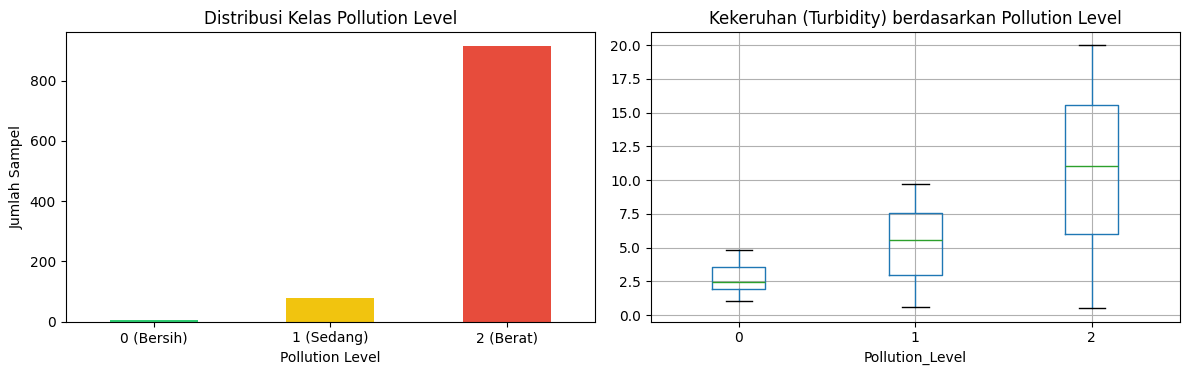

In [ ]:
# ==========================================
# TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# 1. Cek Ringkasan Statistik
print("=== Ringkasan Statistik Dataset ===")
print(df.describe().T[['min', 'mean', 'max']])

# 2. Cek Distribusi Kategori Pollution Level
print("\n=== Sebaran Distribusi Kelas ===")
print(df['Pollution_Level'].value_counts())

# 3. Visualisasi Grafik Distribusi & Boxplot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar Chart Distribusi Kelas
df['Pollution_Level'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#f1c40f', '#e74c3c']
)
axes[0].set_title('Distribusi Kelas Pollution Level')
axes[0].set_xlabel('Pollution Level')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_xticklabels(['0 (Bersih)', '1 (Sedang)', '2 (Berat)'], rotation=0)

# Boxplot Kekeruhan vs Pollution Level
df.boxplot(column='Turbidity (NTU)', by='Pollution_Level', ax=axes[1])
axes[1].set_title('Kekeruhan (Turbidity) berdasarkan Pollution Level')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
# Tentukan kolom fitur dan target
feature_cols = [
    'pH', 'Turbidity (NTU)', 'Temperature (°C)',
    'DO (mg/L)', 'BOD (mg/L)', 'Lead (mg/L)',
    'Mercury (mg/L)', 'Arsenic (mg/L)'
]

X = df[feature_cols]
y = df['Pollution_Level']

# Split Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling Fitur (Standarisasi Sangat Penting untuk Jaringan Saraf / Perceptron)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data berhasil disiapkan dan dinormalisasi!")

Data berhasil disiapkan dan dinormalisasi!


In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
# Penanganan Imbalanced Data menggunakan SMOTE
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Data berhasil di-resample menggunakan SMOTE!")



Data berhasil di-resample menggunakan SMOTE!


In [ ]:
# 1. Algoritma 1: Single Perceptron
single_perceptron = Perceptron(max_iter=1000, random_state=42, class_weight='balanced')
single_perceptron.fit(X_train_scaled, y_train)

# 2. Algoritma 2: Multi-Layer Perceptron (MLP)
mlp_model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=42)
mlp_model.fit(X_train_resampled, y_train_resampled)

# Pelatihan MLP
mlp_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    max_iter=1000,
    activation='relu',
    solver='adam',
    random_state=42
)
mlp_model.fit(X_train_resampled, y_train_resampled)

print("Kedua model berhasil dilatih!")

Kedua model berhasil dilatih!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

=== EVALUASI SINGLE PERCEPTRON ===
Akurasi: 71.50%

              precision    recall  f1-score   support

           0       0.02      1.00      0.04         1
           1       0.14      0.12      0.13        16
           2       0.99      0.77      0.86       183

    accuracy                           0.71       200
   macro avg       0.39      0.63      0.35       200
weighted avg       0.92      0.71      0.80       200

--------------------------------------------------
=== EVALUASI MULTI-LAYER PERCEPTRON (MLP) ===
Akurasi: 92.00%

              precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       0.50      0.38      0.43        16
           2       0.96      0.97      0.96       183

    accuracy                           0.92       200
   macro avg       0.60      0.78      0.63       200
weighted avg       0.92      0.92      0.92       200



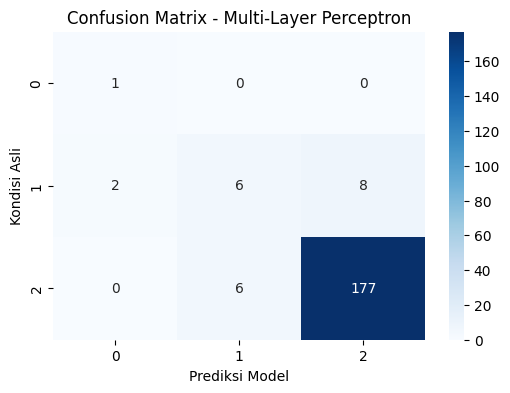

In [ ]:
# =========================================================
# TAHAP 7: EVALUASI MODEL
# =========================================================

# 1. Evaluasi Single Perceptron
y_pred_p = single_perceptron.predict(X_test_scaled)
print("=== EVALUASI SINGLE PERCEPTRON ===")
print(f"Akurasi: {accuracy_score(y_test, y_pred_p) * 100:.2f}%\n")
print(classification_report(y_test, y_pred_p, zero_division=0))

print("-" * 50)

# 2. Evaluasi Multi-Layer Perceptron (MLP)
y_pred_mlp = mlp_model.predict(X_test_scaled)
print("=== EVALUASI MULTI-LAYER PERCEPTRON (MLP) ===")
print(f"Akurasi: {accuracy_score(y_test, y_pred_mlp) * 100:.2f}%\n")
print(classification_report(y_test, y_pred_mlp, zero_division=0))

# Visualisasi Confusion Matrix MLP
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Multi-Layer Perceptron')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Asli')
plt.show()

In [ ]:
# 1. Masukkan Nilai Parameter Air yang Ingin Diprediksi
ph_input = 7.5         # Derajat Keasaman (Standar air bersih: 6.5 - 8.5)
turbidity_input = 1.2   # Kekeruhan (NTU)
temp_input = 22.0       # Suhu (°C)
do_input = 8.2          # Oksigen Terlarut (mg/L)
bod_input = 1.8         # Kebutuhan Oksigen Biokimia (mg/L)
lead_input = 0.0001      # Timbal (mg/L)
mercury_input = 0.0002  # Raksa (mg/L)
arsenic_input = 0.0002   # Arsenik (mg/L)

# 2. Format Data Menjadi DataFrame
data_baru = pd.DataFrame([[
    ph_input, turbidity_input, temp_input,
    do_input, bod_input, lead_input,
    mercury_input, arsenic_input
]], columns=feature_cols)

# 3. Normalisasi Skala Data Menggunakan Scaler yang Sudah Dilatih
data_baru_scaled = scaler.transform(data_baru)

# 4. Prediksi Menggunakan Model MLP / Perceptron
prediksi = mlp_model.predict(data_baru_scaled)[0]

# 5. Keterangan Hasil Prediksi
keterangan = {
    0: "Air Bersih / Layak Digunakan (Pollution Level 0)",
    1: "Tercemar Ringan - Sedang (Pollution Level 1)",
    2: "Tercemar Berat / Tidak Layak Digunakan (Pollution Level 2)"
}

print("=== HASIL PREDIKSI KUALITAS AIR ===")
print(f"Hasil Prediksi AI : Kelas {prediksi}")
print(f"Kategori           : {keterangan[prediksi]}")

=== HASIL PREDIKSI KUALITAS AIR ===
Hasil Prediksi AI : Kelas 0
Kategori           : Air Bersih / Layak Digunakan (Pollution Level 0)
